# **ME630 -Assignment 1 - Problem Statement 8**

**Name:** Meghaj Nandumar Barhate  
**Programme:** M.Tech. in Fluid and Thermal Sciences  
**Roll Number:** 261050047 

---

> # Hollow cylinder with an insulated bore under one-sided flux

Consider a hollow cylinder (tube) of inner radius $R_i$ and outer radius $R_o$. One half of its outer circumference is exposed to a solar-type heat flux, while the entire outer circumference is cooled by convection. The inner bore is insulated.

### Governing Equation

For steady-state conduction with no internal heat generation,

$$
\frac{1}{r}\frac{\partial}{\partial r}
\left(
r\frac{\partial T}{\partial r}
\right)
+
\frac{1}{r^2}\frac{\partial^2 T}{\partial \theta^2}
=0,
\qquad
R_i \leq r \leq R_o,
\quad
0 \leq \theta < 2\pi.
$$

### Boundary Conditions

At the insulated inner surface,

$$
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_i}
=0.
$$

At the outer surface,

$$
-k
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_o}
=
h\left(T(R_o,\theta)-T_\infty\right)-q''(\theta).
$$

The applied circumferential heat flux is

$$
q''(\theta)=
\begin{cases}
q_0''\sin\theta, & 0<\theta<\pi,\\
0, & \pi<\theta<2\pi.
\end{cases}
$$

### Data

$$
R_i = 0.02\ \text{m},
\qquad
R_o = 0.05\ \text{m},
$$

$$
k = 20\ \text{W/(m K)},
\qquad
h = 15\ \text{W/(m}^2\text{ K)},
$$

$$
T_\infty = 25^\circ\text{C},
\qquad
q_0'' = 1200\ \text{W/m}^2.
$$

---

## Analytical Solution

Because the bore at $r=R_i$ is insulated, each harmonic must independently satisfy the zero-gradient condition at $R_i$. Define

$$
f_n(r)=r^n+R_i^{2n}r^{-n},
$$

which automatically satisfies

$$
f_n'(R_i)=0
$$

for every $n$.

Express the applied heat flux as a Fourier series,

$$
q''(\theta)
=
a_0+\sum_{n\geq 1}
\left(
a_n\cos n\theta+b_n\sin n\theta
\right).
$$

For the half-wave-rectified sine distribution,

$$
a_0=\frac{q_0''}{\pi},
\qquad
b_1=\frac{q_0''}{2},
$$

and

$$
a_{2m}
=
-\frac{2q_0''}{\pi(4m^2-1)},
\qquad
m=1,2,3,\ldots
$$

with all other Fourier coefficients equal to zero.

The resulting temperature distribution satisfying both radial boundary conditions is

$$
T(r,\theta)
=
T_\infty
+
\frac{a_0}{h}
+
\frac{b_1f_1(r)}
{hf_1(R_o)+kf_1'(R_o)}
\sin\theta
+
\sum_{m=1}^{\infty}
\frac{a_{2m}f_{2m}(r)}
{hf_{2m}(R_o)+kf_{2m}'(R_o)}
\cos(2m\theta).
$$

### Limiting Check

As $R_i\rightarrow 0$,

$$
f_n(r)\rightarrow r^n,
$$

$$
f_n(R_o)\rightarrow R_o^n,
$$

and

$$
f_n'(R_o)\rightarrow nR_o^{n-1}.
$$

Hence, the hollow-cylinder solution approaches the corresponding solid-cylinder result.

---

## Tasks

### (a) Boundary-Condition Matching

Derive the boundary-condition matching that produces $f_n(r)$ and the coefficient formula given above. Show the algebra that leads from the general radial solution involving $r^n$ and $r^{-n}$ to the stated result.

### (b) Finite-Difference Discretization

Discretize the annulus on a grid with

$$
\Delta r=\frac{R_o-R_i}{M},
\qquad
\Delta\theta=\frac{2\pi}{N},
$$

with periodicity in $\theta$.

No pole treatment is required because the origin is not part of the computational domain. Derive the discretized insulated-bore boundary condition at

$$
r=R_i,
$$

using either a ghost-node formulation or a one-sided finite-difference approximation.

### (c) Numerical Solution and Comparison

Solve the linear system

$$
[A]\{T\}=\{b\}
$$

using:

- a direct method,
- Gauss-Seidel iteration,
- SOR iteration.

Compare the numerical outer-surface temperature $T(R_o,\theta)$ with the analytical-series solution at

$$
\theta=0^\circ,\ 90^\circ,\ 180^\circ,\ 270^\circ.
$$

Also determine the locations and temperatures of the hottest and coldest points on the outer surface.

### (d) Energy-Conservation and Boundary-Condition Verification

Verify overall energy conservation by evaluating

$$
\oint_0^{2\pi}
\left[
q''(\theta)
-
h\left(T(R_o,\theta)-T_\infty\right)
\right]
R_o\,d\theta
\approx 0.
$$

Separately confirm that the radial heat flux at the insulated inner surface,

$$
r=R_i,
$$

is numerically zero everywhere. This serves as a verification of the insulated-bore boundary-condition implementation.

### (e) Limiting-Case Validation

Re-run the annulus solver with the inner radius reduced to

$$
R_i=0.001R_o,
$$

so that the geometry approaches a solid cylinder.

Using the same values of $R_o$, $k$, $h$, $T_\infty$, and $q_0''$, verify that the computed temperature field $T(r,\theta)$ converges to the corresponding solid-cylinder analytical solution.

Report the residual difference as

$$
R_i\rightarrow 0.
$$

---


### Library Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import os
import time as t
%pip install -qq numpy scipy matplotlib psutil ipympl
%matplotlib widget
%matplotlib widget
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Arc

Note: you may need to restart the kernel to use updated packages.


> ## Problem Diagram

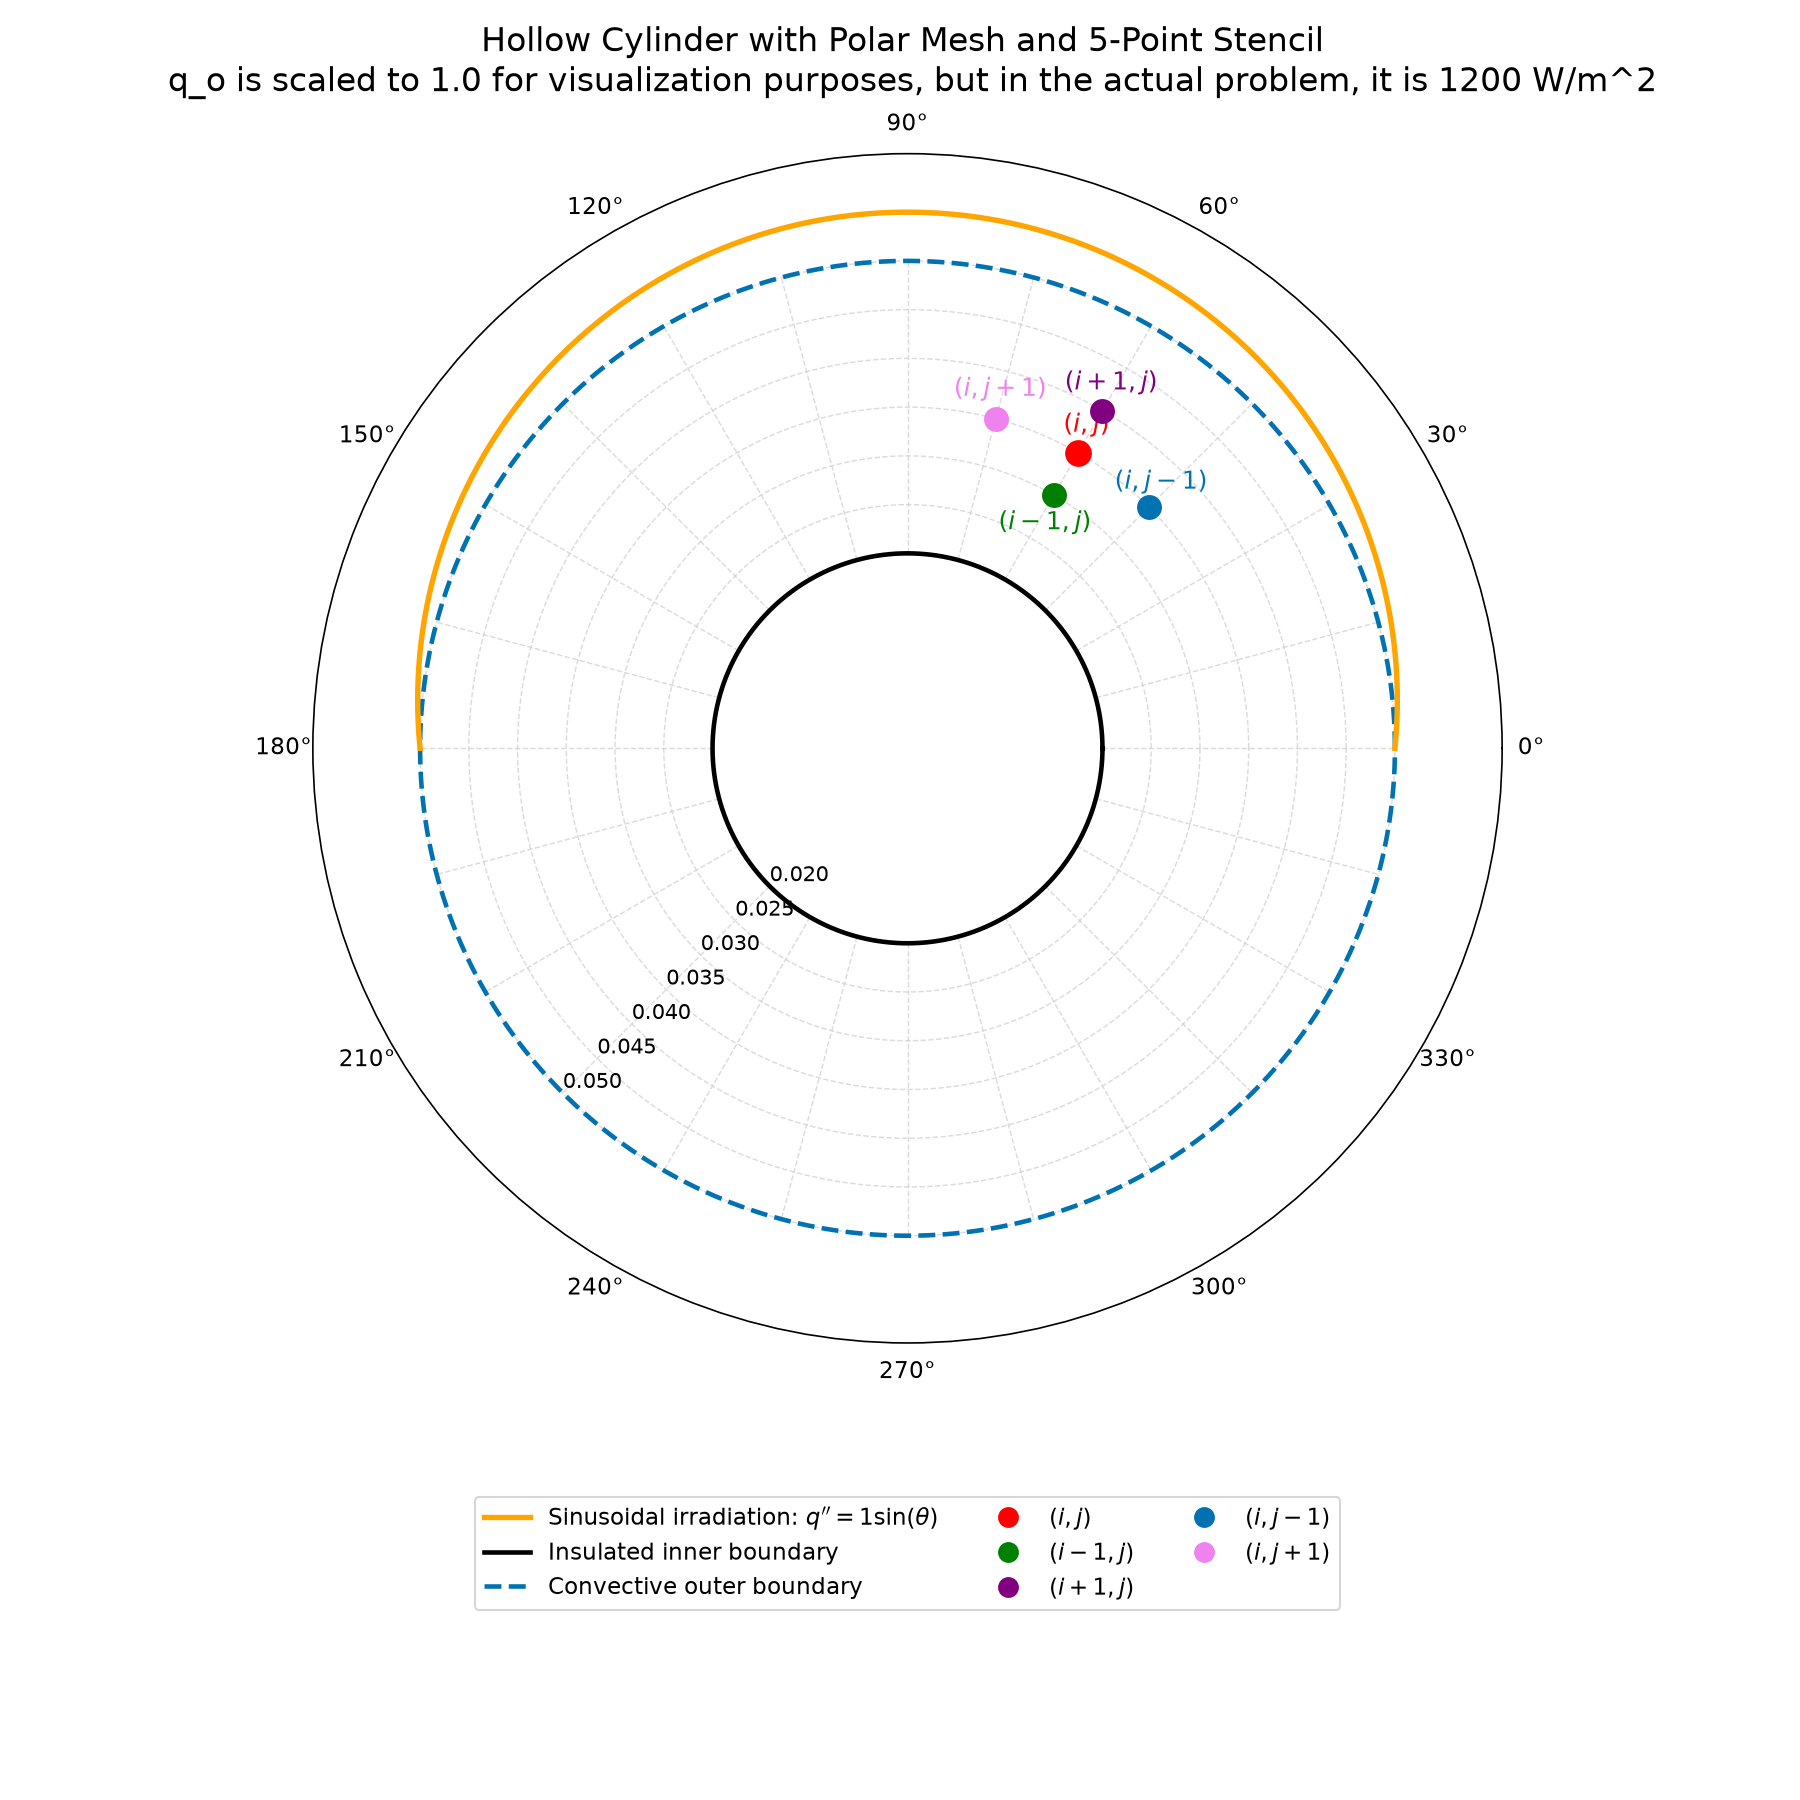

In [2]:
from matplotlib.lines import Line2D

def PlotProblemGeometry(innerRadius, outerRadius, deltaR):
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150, subplot_kw={'projection': 'polar'})
    latexBlue = '#0072B2'
    meshColor = 'lightgrey'
    theta = np.linspace(0, 2 * np.pi, 1000)

    # Polar mesh
    radiusValues = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    for radius in radiusValues:
        ax.plot(theta, np.full_like(theta, radius), linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)
    deltaTheta = np.pi / 12
    thetaValues = np.arange(0, 2 * np.pi, deltaTheta)
    for angle in thetaValues:
        ax.plot([angle, angle], [innerRadius, outerRadius], linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)

    # Boundary conditions
    ax.plot(theta, np.full_like(theta, innerRadius), color='black', linewidth=2.2, zorder=2)
    ax.plot(theta, np.full_like(theta, outerRadius), color=latexBlue, linestyle='--', linewidth=2.2, zorder=2)
    radiationTheta = np.linspace(0, np.pi, 500)
    radiationProfile = 1.0 * np.sin(radiationTheta)
    radiationDisplayScale = deltaR
    radiationRadius = outerRadius + radiationDisplayScale * radiationProfile
    ax.plot(radiationTheta, radiationRadius, color='orange', linewidth=2.6, zorder=3)

    # Five-point dependency map
    pointRadius = innerRadius + 3 * deltaR
    pointTheta = np.pi / 3
    stencilPoints = {
        "(i,j)": (pointTheta, pointRadius),
        "(i,j-1)": (pointTheta - deltaTheta, pointRadius),
        "(i,j+1)": (pointTheta + deltaTheta, pointRadius),
        "(i-1,j)": (pointTheta, pointRadius - deltaR),
        "(i+1,j)": (pointTheta, pointRadius + deltaR)
    }

    ax.scatter(*stencilPoints["(i,j)"], s=140, color='red', zorder=5)
    ax.scatter(*stencilPoints["(i,j-1)"], s=120, color=latexBlue, zorder=5)
    ax.scatter(*stencilPoints["(i,j+1)"], s=120, color='violet', zorder=5)
    ax.scatter(*stencilPoints["(i-1,j)"], s=120, color='green', zorder=5)
    ax.scatter(*stencilPoints["(i+1,j)"], s=120, color='purple', zorder=5)

    textOffset = 0.0018
    ax.text(pointTheta, pointRadius + textOffset, r'$(i,j)$', color='red', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta - deltaTheta, pointRadius + textOffset, r'$(i,j-1)$', color=latexBlue, fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta + deltaTheta, pointRadius + textOffset, r'$(i,j+1)$', color='violet', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta, pointRadius - deltaR - textOffset, r'$(i-1,j)$', color='green', fontsize=12, ha='center', va='top')
    ax.text(pointTheta, pointRadius + deltaR + textOffset, r'$(i+1,j)$', color='purple', fontsize=12, ha='center', va='bottom')

    # Polar axes
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    angleTicks = np.arange(0, 360, 30)
    ax.set_thetagrids(angleTicks, fontsize=11)

    radialTicks = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    ax.set_yticks(radialTicks)
    ax.set_yticklabels([f'{radius:.3f}' for radius in radialTicks], fontsize=10)
    ax.set_rlabel_position(225)
    ax.set_ylim(0, outerRadius + 2.2 * deltaR)
    ax.grid(False)

    legendHandles = [
        Line2D([0], [0], color='orange', linewidth=2.6, label=r'Sinusoidal irradiation: $q^{\prime\prime}=1\sin(\theta)$'),
        Line2D([0], [0], color='black', linewidth=2.2, label='Insulated inner boundary'),
        Line2D([0], [0], color=latexBlue, linestyle='--', linewidth=2.2, label='Convective outer boundary'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=9, label=r'$(i,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=9, label=r'$(i-1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=9, label=r'$(i+1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=latexBlue, markeredgecolor=latexBlue, markersize=9, label=r'$(i,j-1)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=9, label=r'$(i,j+1)$')
    ]

    ax.legend(handles=legendHandles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11, frameon=True)
    ax.set_title('Hollow Cylinder with Polar Mesh and 5-Point Stencil \n q_o is scaled to 1.0 for visualization purposes, but in the actual problem, it is 1200 W/m^2', fontsize=16, pad=30)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

innerRadius = 0.02
outerRadius = 0.05
deltaR = 0.005

PlotProblemGeometry(innerRadius, outerRadius, deltaR)

### Mesh generation

In [3]:
boundaryConditions = ['Dirichlet', 'InnerNeumann', 'Robin']

class PointMapping:
    def __init__(self, radialIndex, angularIndex, outerRadialIndex, innerRadialIndex, cwAngularIndex, ccwAngularIndex):
        self.radialIndex = radialIndex
        self.angularIndex = angularIndex
        self.outerRadialIndex = outerRadialIndex
        self.innerRadialIndex = innerRadialIndex
        self.cwAngularIndex = cwAngularIndex
        self.ccwAngularIndex = ccwAngularIndex
        self.isBoundary = False
        self.boundaryType = None

class ConcentricMesh:
    def __init__(self, innerRadius, outerRadius, radialSteps, angularSteps):
        self.innerRadius = innerRadius
        self.outerRadius = outerRadius
        self.radialSteps = radialSteps
        self.angularSteps = angularSteps
        self.deltaR = (outerRadius - innerRadius) / radialSteps
        self.deltaTheta = 2 * np.pi / angularSteps
        self.nRadii = np.linspace(innerRadius, outerRadius, radialSteps + 1)
        self.nAngles = np.linspace(0, 2 * np.pi, angularSteps + 1)